In [48]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from scipy.optimize import minimize
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [49]:
N_SAMPLES = 200
NOISE = 0.15
N_LAYERS = 3  # 2 params per layer + 2 final = 2*N_LAYERS+2 total params
RANDOM_STATE = 42

X_raw, y_raw = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_STATE)
Y_raw = np.where(y_raw == 1, 1, -1)  # remap sklearn labels 0→-1, 1→+1

print(f"Dataset: {N_SAMPLES} samples, noise={NOISE}")
print(f"Class distribution: {np.sum(Y_raw == 1)} class +1, {np.sum(Y_raw == -1)} class -1")


Dataset: 200 samples, noise=0.15
Class distribution: 100 class +1, 100 class -1


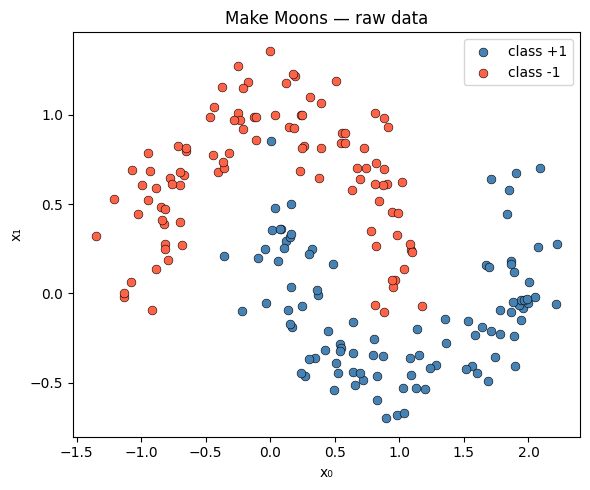

In [50]:
colors = {1: "steelblue", -1: "tomato"}
fig, ax = plt.subplots(figsize=(6, 5))
for label in [1, -1]:
    mask = Y_raw == label
    ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors[label], edgecolors="k",
               linewidths=0.4, s=40, label=f"class {label:+d}")
ax.set_xlabel("x₀")
ax.set_ylabel("x₁")
ax.set_title("Make Moons — raw data")
ax.legend()
plt.tight_layout()
plt.show()

In [51]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_raw, Y_raw, test_size=0.25, random_state=RANDOM_STATE
)

X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
X_train = (X_train - X_min) / (X_max - X_min)
X_test  = (X_test  - X_min) / (X_max - X_min)

print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")

Train: 150 samples  |  Test: 50 samples


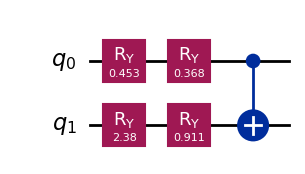

In [52]:
def layer(qc, x, theta, theta_offset):
    """One re-uploading layer: encode x into Ry rotations, apply trainable Ry rotations, then entangle."""
    qc.ry(np.pi * x[0], 0)
    qc.ry(np.pi * x[1], 1)
    qc.ry(theta[theta_offset + 0], 0)
    qc.ry(theta[theta_offset + 1], 1)
    qc.cx(0, 1)

theta_demo = np.random.rand(2 * N_LAYERS + 2)
qc_single = QuantumCircuit(2)
layer(qc_single, X_train[0], theta_demo, theta_offset=0)
qc_single.draw(output="mpl")


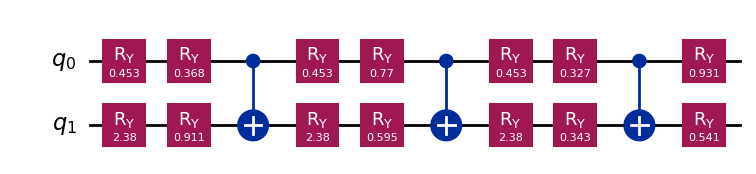

In [53]:
def classifier_head(qc, theta):
    qc.ry(theta[-2], 0)
    qc.ry(theta[-1], 1)

def build_circuit(x, theta):
    qc = QuantumCircuit(2)
    for l in range(N_LAYERS):
        layer(qc, x, theta, theta_offset=l * 2)
    classifier_head(qc, theta)
    return qc

build_circuit(X_train[0], theta_demo).draw(output="mpl")


In [54]:
n_params = 2 * N_LAYERS + 2
print(f"N_LAYERS={N_LAYERS}  →  {n_params} total parameters")
print(f"Architecture: {N_LAYERS} × [Ry(π·x₀) Ry(π·x₁) Ry(θ) Ry(θ) CX]  +  classifier head [Ry(θ) Ry(θ)]")
print("Re-uploading: input x is re-encoded at every layer")


N_LAYERS=3  →  8 total parameters
Architecture: 3 × [Ry(π·x₀) Ry(π·x₁) Ry(θ) Ry(θ) CX]  +  classifier head [Ry(θ) Ry(θ)]
Re-uploading: input x is re-encoded at every layer


In [55]:
def forward(x, theta):
    qc = build_circuit(x, theta)
    state = Statevector.from_instruction(qc)
    return float(np.real(state.expectation_value([[1, 0], [0, -1]], [0])))

In [56]:
def loss(theta, X, Y):
    preds = np.array([forward(x, theta) for x in X])
    return float(np.mean((preds - Y) ** 2))

In [57]:
theta0 = np.random.rand(2 * N_LAYERS + 2)
result = minimize(loss, theta0, args=(X_train, Y_train), method='COBYLA',
                  options={'maxiter': 1000})
theta_opt = result.x

print("Optimized theta:", theta_opt)
print("Final train loss:", result.fun)


Optimized theta: [-0.27917894 -0.81863492  3.6092606  -1.02700471  0.91349563  1.91918886
  1.05885215  0.96178328]
Final train loss: 0.15551999153993581


In [58]:
pred_labels_train = np.array([1 if forward(x, theta_opt) >= 0 else -1 for x in X_train])
pred_labels_test  = np.array([1 if forward(x, theta_opt) >= 0 else -1 for x in X_test])
accuracy_train = np.mean(pred_labels_train == Y_train)
accuracy_test  = np.mean(pred_labels_test  == Y_test)

print(f"VQC Train Accuracy: {accuracy_train:.3f}")
print(f"VQC Test  Accuracy: {accuracy_test:.3f}")

VQC Train Accuracy: 0.980
VQC Test  Accuracy: 0.980


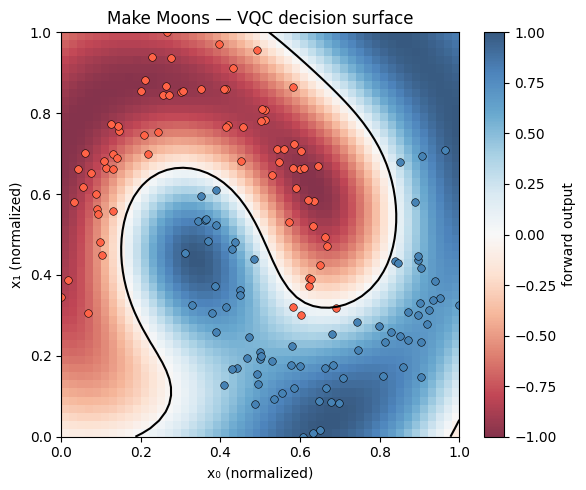

In [59]:
resolution = 50
grid = np.linspace(0, 1, resolution)
g0, g1 = np.meshgrid(grid, grid)

Z_vqc_values = []
for a, b in zip(g0.ravel(), g1.ravel()):
    Z_vqc_values.append(forward(np.array([a, b]), theta_opt))
Z_vqc = np.array(Z_vqc_values).reshape(resolution, resolution)

colors_map = {1: "steelblue", -1: "tomato"}
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Z_vqc, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.8)
ax.contour(g0, g1, Z_vqc, levels=[0], colors="k", linewidths=1.5)
plt.colorbar(im, ax=ax, label="forward output")
for xi, yi in zip(X_train, Y_train):
    ax.scatter(xi[0], xi[1], c=colors_map[yi], edgecolors="k", linewidths=0.4, s=30)
ax.set_xlabel("x₀ (normalized)")
ax.set_ylabel("x₁ (normalized)")
ax.set_title("Make Moons — VQC decision surface")
plt.tight_layout()
plt.show()

In [60]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation='tanh',
    solver='adam',
    alpha=1e-4,
    max_iter=5000,
    random_state=RANDOM_STATE,
 )
mlp.fit(X_train, Y_train)

print(f"MLP Train Accuracy: {np.mean(mlp.predict(X_train) == Y_train):.3f}")
print(f"MLP Test  Accuracy: {np.mean(mlp.predict(X_test)  == Y_test):.3f}")
print()
print(f"VQC Train Accuracy: {accuracy_train:.3f}")
print(f"VQC Test  Accuracy: {accuracy_test:.3f}")

MLP Train Accuracy: 0.860
MLP Test  Accuracy: 0.840

VQC Train Accuracy: 0.980
VQC Test  Accuracy: 0.980


In [61]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, Y_train)

print(f"SVM (RBF) Train Accuracy: {np.mean(svm.predict(X_train) == Y_train):.3f}")
print(f"SVM (RBF) Test  Accuracy: {np.mean(svm.predict(X_test)  == Y_test):.3f}")

SVM (RBF) Train Accuracy: 0.980
SVM (RBF) Test  Accuracy: 0.980


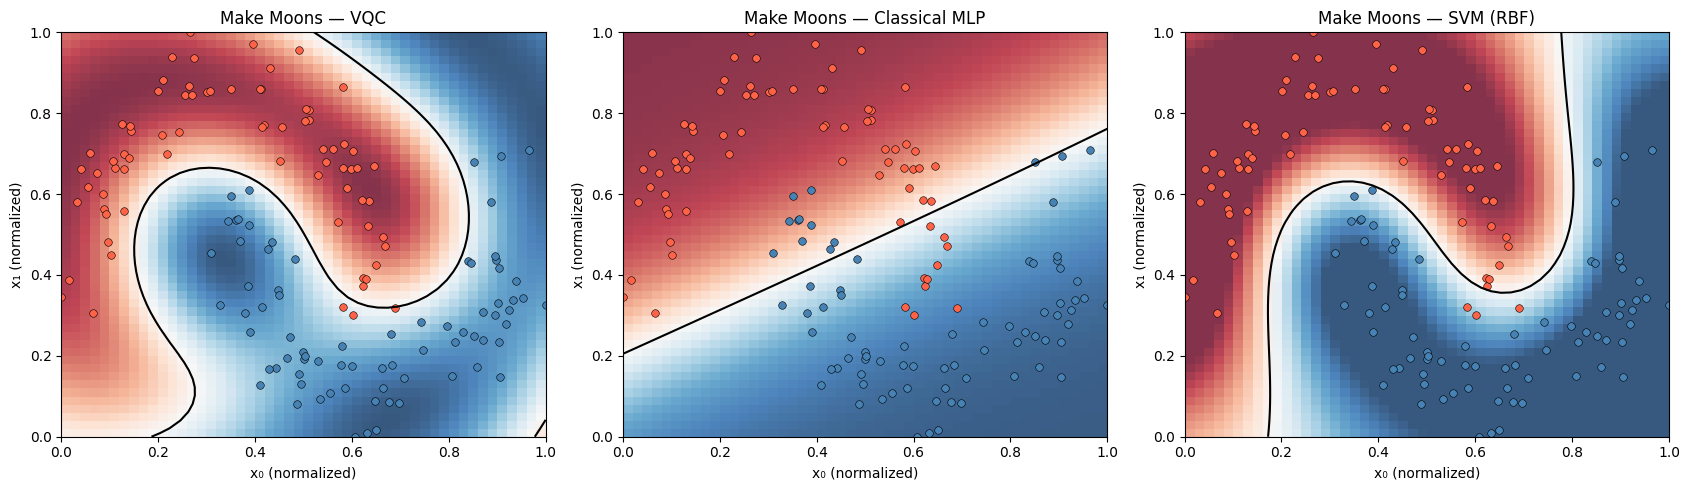

In [62]:
grid_2d = np.column_stack([g0.ravel(), g1.ravel()])

# Use continuous scores so all three plots render with gradients like the VQC
Z_mlp = (mlp.predict_proba(grid_2d)[:, 1] * 2 - 1).reshape(resolution, resolution)
Z_svm = svm.decision_function(grid_2d).reshape(resolution, resolution)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, Z, title in zip(axes, [Z_vqc, Z_mlp, Z_svm], ["VQC", "Classical MLP", "SVM (RBF)"]):
    ax.imshow(Z, extent=[0, 1, 0, 1], origin="lower", cmap="RdBu", vmin=-1, vmax=1, aspect="auto", alpha=0.8)
    ax.contour(g0, g1, Z, levels=[0], colors="k", linewidths=1.5)
    for xi, yi in zip(X_train, Y_train):
        ax.scatter(xi[0], xi[1], c=colors_map[yi], edgecolors="k", linewidths=0.4, s=30)
    ax.set_xlabel("x₀ (normalized)")
    ax.set_ylabel("x₁ (normalized)")
    ax.set_title(f"Make Moons — {title}")

plt.tight_layout()
plt.show()
